## **Task: SIG731 : Task 3P - Working with numpy Matrices (Multidimensional Data)**

#### **Name: Isha Shukla**
#### Student number: 225170943
#### E-mail - isha03shukla04@gmail.com

### Introduction

This report demonstrates the use of **NumPy matrices(Multi-Dimensional Data) for data wrangling**, analysis, and visualization. It is based on body measurement data from the **National Health and Nutrition Examination Survey (NHANES)**, focusing on adult **males and females**. The primary objective is to calculate and analyze Body Mass Index (BMI) values for both groups while exploring relationships between various body measurements.

Throughout this task, we address key data analysis techniques, including:

- Loading and processing multidimensional datasets with NumPy.
- Visualizing data through histograms, boxplots, and scatterplot matrices.
- Computing statistical measures (mean, median, standard deviation, skewness, and correlations).
- Standardizing data and observing the effects of normalization.

By following these steps, we aim to gain insights into the distributions of BMI, assess inter-variable correlations, and standardize datasets for comparative analysis. The code and discussions are presented systematically, ensuring clarity and a professional approach.

### Import necessary libraries

In [1]:
import warnings 
warnings.filterwarnings('ignore', '.*do not.*', ) 

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, iqr, pearsonr, spearmanr

#### Q1. From https://github.com/gagolews/teaching-data/tree/master/marek, download the two following excerpts from the National Health and Nutrition Examination Survey (NHANES dataset) that give body measurements of adult males and females.

In [2]:
male_data = '/Users/ishashukla/Downloads/nhanes_adult_male_bmx_2020.csv'
female_data = '/Users/ishashukla/Downloads/nhanes_adult_female_bmx_2020.csv'

#### Q2. Read them as numpy matrices named male and female using numpy.genfromtxt. Each matrix consists of seven columns:
    1. weight (kg),
    2. standing height (cm),
    3. upper arm length (cm),
    4. upper leg length (cm),
    5. arm circumference (cm),
    6. hip circumference (cm),
    7. waist circumference (cm).

In [3]:
# Read the data as NumPy matrices
male = np.genfromtxt(male_data, delimiter=',', skip_header=1,dtype=float)
female = np.genfromtxt(female_data, delimiter=',', skip_header=1,dtype=float)

# Display the shapes of the matrices to verify successful loading
print(f"Male matrix shape: {male.shape}")
print(f"Female matrix shape: {female.shape}")

Male matrix shape: (4082, 7)
Female matrix shape: (4222, 7)


In [4]:
column_names=['weight', 'standing height', 'upper arm length ', 'upper leg length', 
                'arm circumference', 'hip circumference', 'waist circumference']

In [5]:
# Save the male data with header
m=np.savetxt('male.csv', male, delimiter=',', header=','.join(column_names), comments='', fmt='%0.2f')

# Save the female data with header
n=np.savetxt('female.csv', female, delimiter=',', header=','.join(column_names), comments='', fmt='%0.2f')

print("CSV files with headers saved!")

CSV files with headers saved!


####  Q3. In both cases, add the eight column which stores the body mass indices of the participants.
######  BMI = weight(kg) / (height(m)^2)

In [6]:
# Calculate BMI for male and female participants
# BMI = weight(kg) / (height(m)^2)
male_BMI = male[:, 0] / ((male[:, 1] / 100) ** 2)  # Convert height from cm to meters
female_BMI = female[:, 0] / ((female[:, 1] / 100) ** 2)

# Add the BMI column to the male and female matrices
male = np.hstack((male, male_BMI[:, None]))  # Add BMI as the 8th column
female = np.hstack((female, female_BMI[:, None]))

# Display the first few rows to verify
print("First 5 rows of the male matrix with BMI:")
print(male[:5])

print("\nFirst 5 rows of the female matrix with BMI:")
print(female[:5])

First 5 rows of the male matrix with BMI:
[[         nan          nan          nan          nan          nan
           nan          nan          nan]
 [ 98.8        182.3         42.          40.1         38.2
  108.2        120.4         29.72922633]
 [ 74.3        184.2         41.1         41.          30.2
   94.5         86.8         21.89825769]
 [103.7        185.3         47.          44.          32.
  107.8        109.6         30.20145858]
 [ 86.         167.8         39.5         38.4         29.
  106.4        108.3         30.54320016]]

First 5 rows of the female matrix with BMI:
[[         nan          nan          nan          nan          nan
           nan          nan          nan]
 [ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9         37.83504078]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1         39.06972037]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.     

#### Q4. On a single plot, draw two histograms: for male BMIs (top subfigure) and for female BMIs(bottom subfigure) one below another. Set the number of histogram bins to 20. Use matplotlib.pyplot.subplot to create two subplots in one figure. Call matplotlib.pyplot.xlim to make the x-axis limits identical for both subfigures (work out the appropriate limits yourself). 

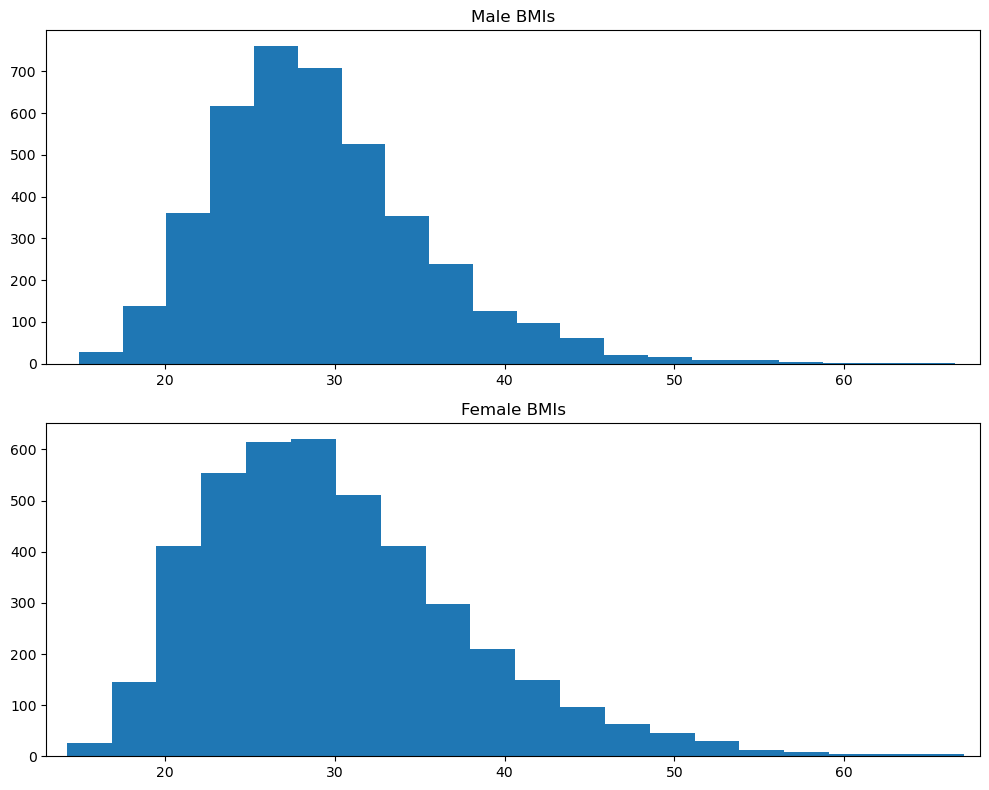

In [7]:
# Remove rows with NaN values in BMI
male = male[~np.isnan(male[:, 7])]  # Keep rows where BMI is not NaN
female = female[~np.isnan(female[:, 7])]  # Same for female

# Set x-axis limits based on BMI values
min_bmi = min(male[:, 7].min(), female[:, 7].min())
max_bmi = max(male[:, 7].max(), female[:, 7].max())
x_limits = (int(min_bmi) - 1, int(max_bmi) + 1)  # Add a small margin for better visualization

# Create the figure and subplots
plt.figure(figsize=(10, 8))

# Histogram for male BMIs
plt.subplot(2, 1, 1)  # 2 rows, 1 column, first plot
plt.hist(male[:, 7], bins=20)
plt.xlim(x_limits)
plt.title('Male BMIs')
#plt.legend()

# Histogram for female BMIs
plt.subplot(2, 1, 2)  # 2 rows, 1 column, second plot
plt.hist(female[:, 7], bins=20)
plt.xlim(x_limits)
plt.title('Female BMIs')
#plt.legend()

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

- Females have a higher average BMI compared to males.
- The BMI distribution for females shows greater variability.
- Both distributions are right-skewed, meaning there are more individuals with higher BMI values in both groups.

#### Q5. Using a single call to matplotlib.pyplot.boxplot, draw a box-and-whisker plot giving the male and female BMIs, with two boxes one below another (on one plot) so that they can be compared to each other. Note that the boxplot function can be fed with a list of two vectors like [male_BMIs, female_BMIs].

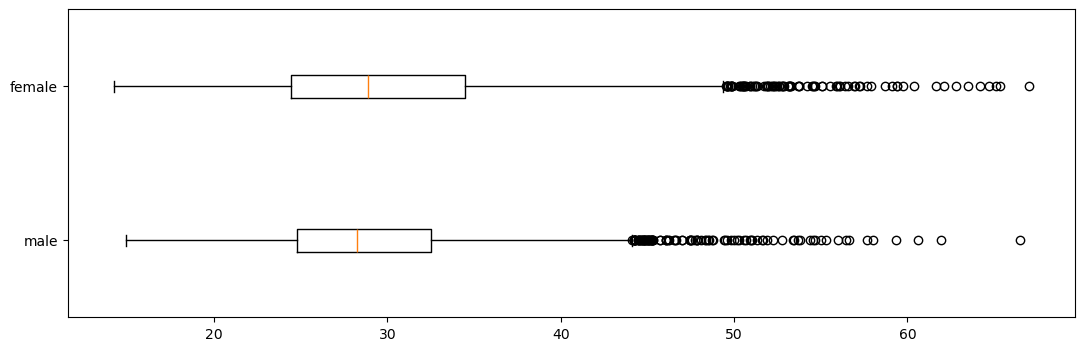

In [8]:
# Extract the BMI column (8th column, index 7)
male_BMIs = male[:, 7]
female_BMIs = female[:, 7]

# Create the box-and-whisker plot
plt.figure(figsize=(13, 4))
plt.boxplot([male_BMIs, female_BMIs], vert=False,labels=['male', 'female'])

# Show the plot
plt.show()

- There are `several outliers` for both groups, with values exceeding 40 and extending up to around 65 for both females and males.
- Boxplot shows that males and females are both `right skewed`.
- The median BMI for `females is around 30`, while for `males`, it is slightly lower, `around 28`.
- The IQR for `females spans from approximately 25 to 35`.
- The IQR for `males spans from approximately 26 to 32`.

#### Q6. Compute the basic numerical aggregates of the male and female BMIs (measures of location, dispersion, and shape). Report them in a readable format. Example formatting of the aggregates:

In [9]:
# Funtion to calculate aggregates
def calculate_aggregates(bmi):
    return {
        "mean": np.mean(bmi),
        "median": np.median(bmi),
        "min": np.min(bmi),
        "max": np.max(bmi),
        "std": np.std(bmi),
        "IQR": np.percentile(bmi, 75) - np.percentile(bmi, 25),
        "skew": skew(bmi)
    }

female_aggregates = calculate_aggregates(female_BMIs)
male_aggregates = calculate_aggregates(male_BMIs)

- **Mean:** The sum of all values divided by the number of values; represents the dataset's average.
- **Median:** The middle value in the dataset when ordered, or the average of the two middle values if the dataset size is even.
- **Minimum:** The smallest value in the dataset.
- **Maximum:** The largest value in the dataset.
- **Standard Deviation:** A measure of the spread of values around the mean, indicating the dataset's variability.
- **Interquartile Range (IQR):** The range between the first quartile (Q1) and the third quartile (Q3), measuring the middle 50% of the data.
- **skew:** Skewness is the degree of asymmetry observed in a probability distribution. 

In [10]:
print(f"##               female   male")
print(f"## BMI mean      {female_aggregates['mean']:.2f}    {male_aggregates['mean']:.2f}")
print(f"## median        {female_aggregates['median']:.2f}    {male_aggregates['median']:.2f}")
print(f"## min           {female_aggregates['min']:.2f}    {male_aggregates['min']:.2f}")
print(f"## max           {female_aggregates['max']:.2f}    {male_aggregates['max']:.2f}")
print(f"## std           {female_aggregates['std']:.2f}     {male_aggregates['std']:.2f}")
print(f"## IQR           {female_aggregates['IQR']:.2f}    {male_aggregates['IQR']:.2f}")
print(f"## skew          {female_aggregates['skew']:.2f}     {male_aggregates['skew']:.2f}")

##               female   male
## BMI mean      30.10    29.14
## median        28.89    28.27
## min           14.20    14.91
## max           67.04    66.50
## std           7.76     6.31
## IQR           10.01    7.73
## skew          0.92     0.97


#### Q7. In your own words, describe the two distributions based on the results obtained in subtasks Q4, Q5, and Q6 above (e.g., are they left-skewed, how they differ, which one has more dispersion, and so forth).

Based on the BMI data and distributions for males and females, here are the observations:

- **Central Tendency**:
  - **Females**: Mean BMI is 30.10, and the median BMI is 28.89.
  - **Males**: Mean BMI is 29.14, and the median BMI is 28.27.

- **Dispersion**:
  - The female BMI distribution shows more dispersion compared to the male BMI distribution. This is indicated by the higher standard deviation (7.76 for females vs. 6.31 for males) and the larger interquartile range (IQR) of 10.01 for females compared to 7.73 for males.

This greater dispersion means that BMI values among females are more spread out and varied than those among males.

- **Range**:
  - **Females**: Minimum BMI is 14.20, and the maximum BMI is 67.04.
  - **Males**: Minimum BMI is 14.91, and the maximum BMI is 66.50.

- **Skewness**:
  - Both distributions are right-skewed, with skewness values of 0.92 for females and 0.97 for males.

**Observations**:

1. Females have a higher average BMI and median BMI compared to males.
2. The BMI distribution for females shows greater variability, indicated by higher standard deviation and IQR values.
3. The range of BMI values is slightly wider for females, with a lower minimum and a higher maximum.
4. Both distributions are right-skewed, meaning there are more individuals with higher BMI values in both groups.

These observations highlight the differences and similarities in BMI distributions between males and females, indicating that females tend to have higher and more varied BMI values compared to males.

#### Q8. Draw a scatterplot matrix (pairplot) for the male heights, weights, waist circumferences, hip circumferences, and BMIs (these five columns only); see the pairplot function in section 7.4.3 of our book.

In [11]:
def pairplot(X, labels, bins=21, alpha=0.1):
    """
    Draws a scatter plot matrix, given:
    * X - data matrix,
    * labels - list of column names
    """
    assert X.shape[1] == len(labels)

    k = X.shape[1]
    fig, axes = plt.subplots(nrows=k, ncols=k, sharex="col", sharey="row",
        figsize=(plt.rcParams["figure.figsize"][0], )*2)
    for i in range(k):
        for j in range(k):
            ax = axes[i, j]
            if i == j:  # diagonal
                ax.text(0.5, 0.5, labels[i], transform=ax.transAxes,
                    ha="center", va="center", size="x-small")
            else:
                ax.plot(X[:, j], X[:, i], ".", color="black", alpha=alpha)

In [12]:
X = male[:, [1, 0, 6, 5, 7]] #
labels = ['height', 'weight', 'waist', 'hip', 'BMI']

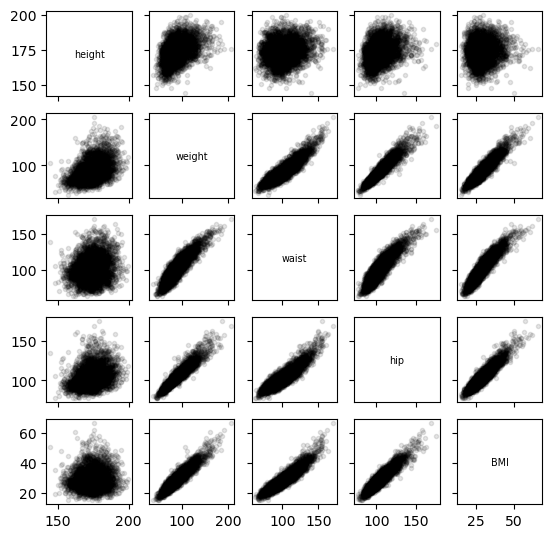

In [13]:
# Create the pairplot using seaborn without pandas
pairplot(X,labels)

# Show the plot
plt.show()

A pairplot is a powerful visualization tool that provides a comprehensive overview of the relationships between multiple variables. Here's a detailed observation of the pairplot:

1. **Diagonal Cells**: These cells display the distribution of each variable individually, often represented by histograms or density plots. It shows how each variable is spread out across its range of values.

2. **Scatter Plots**: The off-diagonal cells represent scatter plots for pairs of variables, allowing for the examination of potential correlations and patterns between them.
    - **Height vs. Weight**: There appears to be a positive correlation, meaning that as height increases, weight tends to increase as well.
    - **Height vs. BMI**: A moderate positive correlation is visible; taller individuals tend to have higher BMI.
    - **Weight vs. Waist**: A strong positive correlation is observed, indicating that individuals with higher weight also tend to have larger waist measurements.
    - **Weight vs. Hip**: Similarly, a positive correlation exists, showing that as weight increases, hip measurements tend to increase as well.
    - **Waist vs. Hip**: A very strong positive correlation can be seen, suggesting that waist and hip measurements tend to increase together.

3. **Outliers**: Some scatter plots may show outliers, points that deviate significantly from the general pattern, which can indicate unusual data points that may need further investigation.

4. **Trends and Patterns**: Overall, the pairplot provides insights into the relationships between variables such as height, weight, waist, hip, and BMI. Positive correlations between these variables suggest that they tend to increase together.

This pairplot helps in understanding the interrelationships between multiple variables, offering a holistic view of the dataset.

#### Q9. Compute Pearson’s and Spearman’s correlation coefficients for all pairs of variables mentioned in subtask Q8. Present/visualise these coefficients on two correlation heatmaps (with correlation coefficients printed inside the coloured cells); see the corrheatmap function in Section 9.1.2 of our book. 

In [14]:
def corrheatmap(R, labels):
    """
    Draws a correlation heat map, given:
    * R - matrix of correlation coefficients for all variable pairs,
    * labels - list of column names
    """
    assert R.shape[0] == R.shape[1] and R.shape[0] == len(labels)
    k = R.shape[0]

    # plot the heat map using a custom colour palette
    # (correlations are in [-1, 1])
    plt.imshow(R, cmap=plt.colormaps.get_cmap("RdBu"), vmin=-1, vmax=1)

    # add text labels
    for i in range(k):
        for j in range(k):
            plt.text(i, j, f"{R[i, j]:.2f}", ha="center", va="center",
                color="black" if np.abs(R[i, j])<0.5 else "white")

    plt.xticks(np.arange(k), labels=labels, rotation=30)
    plt.tick_params(axis="x", which="both",
        labelbottom=True, labeltop=True, bottom=False, top=False)

    plt.yticks(np.arange(k), labels=labels)
    plt.tick_params(axis="y", which="both",
        labelleft=True, labelright=True, left=False, right=False)

    plt.grid(False)

In [15]:
# Compute Pearson's correlation matrix
pearson_corr = np.corrcoef(X, rowvar=False)

# Compute Spearman's correlation matrix
spearman_corr, _ = spearmanr(X, axis=0)

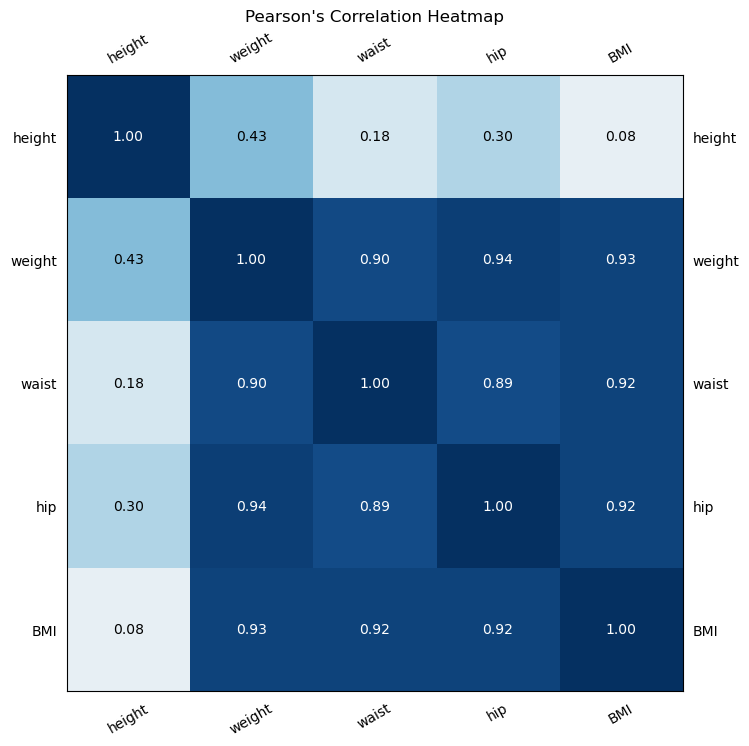

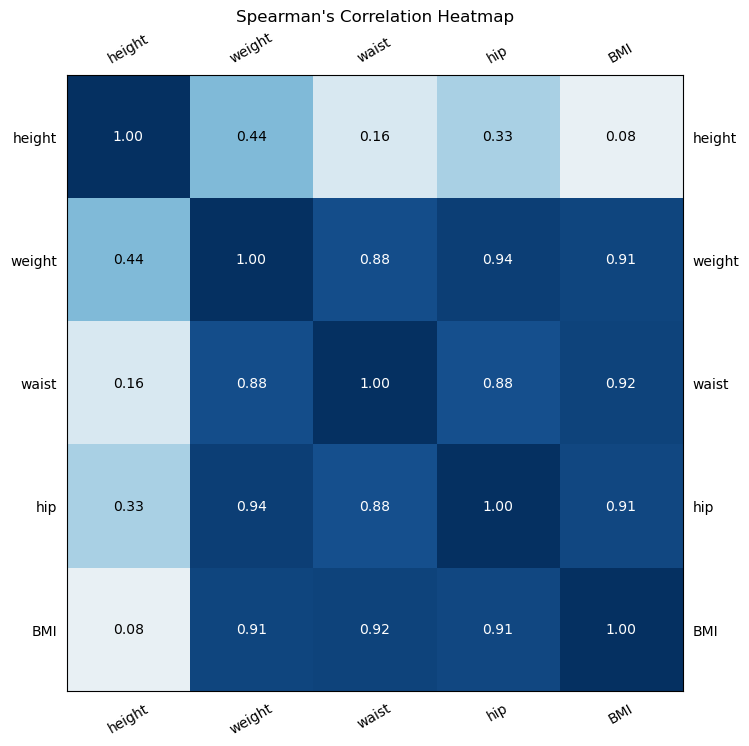

In [16]:
# Plot Pearson's correlation heatmap

plt.figure(figsize=(10, 8))  # width=height
plt.title("Pearson's Correlation Heatmap")
corrheatmap(pearson_corr, labels)
plt.show()

# Plot Spearman's correlation heatmap
plt.figure(figsize=(10, 8))  # width=height
plt.title("Spearman's Correlation Heatmap")
corrheatmap(spearman_corr, labels)
plt.show()

**Pearson Observation**: The Pearson correlation analysis revealed several key insights regarding the relationships between height, weight, waist, hip, and BMI. `Height has a weak positive correlation with other variables`, suggesting that it does not significantly influence weight, waist, hip, or BMI. In contrast, weight, waist, hip, and BMI exhibit strong positive correlations with one another. Specifically, weight has strong correlations with waist (0.90), hip (0.94), and BMI (0.93). Similarly, waist shows strong correlations with weight (0.90), hip (0.89), and BMI (0.92). Hip measurements are strongly correlated with weight (0.94), waist (0.89), and BMI (0.92). Lastly, BMI has strong correlations with weight (0.93), waist (0.92), and hip (0.92). 

**The strongest correlation observed is between weight and hip measurements, with a correlation coefficient of 0.94.** These strong correlations indicate that as one of these measurements increases, the others tend to increase as well, highlighting their interrelated nature. Overall, the analysis underscores the importance of considering these body measurements together when assessing an individual's health and body composition.

---

**Spearman Observation:** The Spearman correlation analysis provided key insights into the relationships between height, weight, waist, hip, and BMI. Height shows a weak positive correlation with other variables, suggesting it does not significantly influence weight, waist, hip, or BMI. In contrast, weight, waist, hip, and BMI exhibit strong positive correlations with one another.

- Weight has strong correlations with waist (0.88), hip (**0.94**), and BMI (0.91).
- Waist shows strong correlations with weight (0.88), hip (0.88), and BMI (0.92).
- Hip measurements are strongly correlated with weight (**0.94**), waist (0.88), and BMI (0.91).
- BMI has strong correlations with weight (0.91), waist (0.92), and hip (0.91).

**The strongest correlation observed is between weight and hip measurements, with a correlation coefficient of 0.94.** These strong correlations indicate that as one of these measurements increases, the others tend to increase as well, highlighting their interrelated nature. Overall, the analysis emphasizes the importance of considering these body measurements together when assessing an individual's health and body composition.

#### Q10. Discuss the findings from subtasks Q8 and Q9.

The provided pairplot offers a detailed visualization of the relationships between multiple body composition variables, specifically height, weight, waist, hip, and BMI. The graph aligns with the observations noted and can be summarized as follows:

---

### **Key Observations from the Pairplot:**
1. **Diagonal Cells (Distributions):**
   - Each variable's distribution is shown, providing insights into their spread and potential skewness.
   - For example, the BMI distribution appears slightly skewed, while height is more symmetrically distributed.

2. **Scatterplots (Off-Diagonal Cells):**
   - **Height vs. Other Variables:** 
     - Weak positive correlations are observed, as height does not strongly influence weight, waist, hip, or BMI.
   - **Weight vs. Waist, Hip, and BMI:** 
     - Clear strong positive correlations are evident, indicating interdependence.
     - Particularly notable is the very strong correlation between **weight and hip**.
   - **Waist vs. Hip and BMI:** 
     - Strong positive trends are apparent, suggesting that as waist circumference increases, so do hip and BMI values.

3. **Outliers:**
   - A few points deviate from the overall trend, indicating potential anomalies or unique data points worth investigating.

4. **Ranges (Standardized Data):**
   - The z-scores standardize the data, scaling it within a range approximately between -3 and 3. This ensures the values are comparable across different variables.

---

### **Highlights from Correlation Analysis:**
- **Strongest Correlation:** Between weight and hip measurements (**0.94**).
- Other high correlations include:
  - Weight and BMI (**0.93**).
  - Waist and BMI (**0.92**).
  - Waist and Hip (**0.89**).
- These correlations indicate that measurements like weight, waist, hip, and BMI are highly interrelated.

---

### **Conclusion:**
The pairplot reinforces the findings from the Pearson and Spearman correlation analyses. It provides a clear visualization of the positive relationships between weight, waist, hip, and BMI, and emphasizes that height is relatively independent. These relationships are critical for understanding body composition dynamics and their implications for health assessments.

#### Q11. Create a new matrix zmale being a version of the male dataset with each of its eight columns standardised (by computing the z-scores of each column).

The z-score is a statistical measure that represents how many standard deviations a data point is from the mean of the dataset. It is used to standardize variables so that they can be compared on the same scale, even if they have different units or ranges.

In [17]:
# Compute the mean and standard deviation for each column
mean = np.mean(male, axis=0)
std_dev = np.std(male, axis=0)

# Compute the z-scores (standardized values)
zmale = (male - mean) / std_dev

# Print the standardized matrix
print("Standardized (z-scores) male matrix:")
print(zmale)

Standardized (z-scores) male matrix:
[[ 0.48720705  1.10591976  1.14339753 ...  0.30342312  1.12527144
   0.09285103]
 [-0.65664058  1.35391391  0.77389142 ... -0.81857635 -0.90632075
  -1.14778251]
 [ 0.71597658  1.49748947  3.19620928 ...  0.27066401  0.47225967
   0.16766517]
 ...
 [ 0.95408363 -0.66919624 -0.25251446 ...  1.10602127  0.78062634
   1.43952184]
 [-0.41386476  0.33583267  0.11699166 ... -0.38451816 -0.283541
  -0.56944462]
 [-1.33828039 -0.82582412  0.44544154 ... -1.14616744 -0.90027434
  -1.24593988]]


#### Q12. Perform the aforementioned subtasks Q8–Q10 on zmale instead of on the original male dataset(do not include two pairplots nor four heatmaps).

In [18]:
X_zmale = zmale[:, [1, 0, 6, 5, 7]] #
labels = ['height', 'weight', 'waist', 'hip', 'BMI']

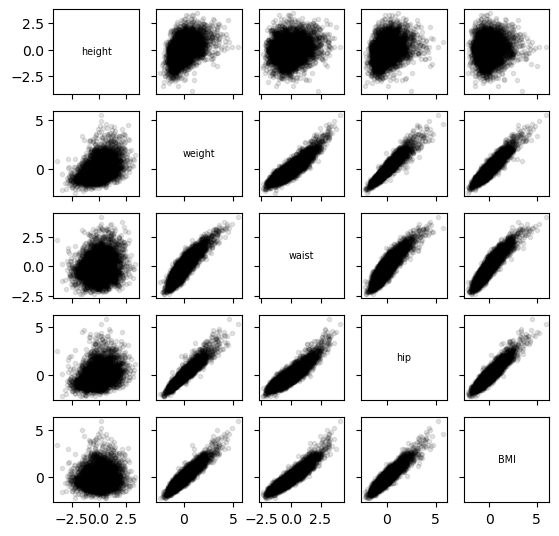

In [19]:
# Generate the pairplot for zmale
pairplot(X_zmale, labels)

In [20]:
# Pearson correlation matrix for zmale
pearson_corr_zmale = np.corrcoef(X_zmale, rowvar=False)

# Spearman correlation matrix for zmale
spearman_corr_zmale, _ = spearmanr(X_zmale, axis=0)

print("Pearson's Correlation Matrix for zmale:")
print(pearson_corr_zmale)

print("\nSpearman's Correlation Matrix for zmale:")
print(spearman_corr_zmale)

Pearson's Correlation Matrix for zmale:
[[1.         0.43415325 0.17573744 0.30223617 0.08040292]
 [0.43415325 1.         0.89894646 0.94190019 0.92936375]
 [0.17573744 0.89894646 1.         0.89469332 0.92423935]
 [0.30223617 0.94190019 0.89469332 1.         0.92459752]
 [0.08040292 0.92936375 0.92423935 0.92459752 1.        ]]

Spearman's Correlation Matrix for zmale:
[[1.         0.43946118 0.16276749 0.32590382 0.07501347]
 [0.43946118 1.         0.88436584 0.94391654 0.91492083]
 [0.16276749 0.88436584 1.         0.87960809 0.92203332]
 [0.32590382 0.94391654 0.87960809 1.         0.90647019]
 [0.07501347 0.91492083 0.92203332 0.90647019 1.        ]]


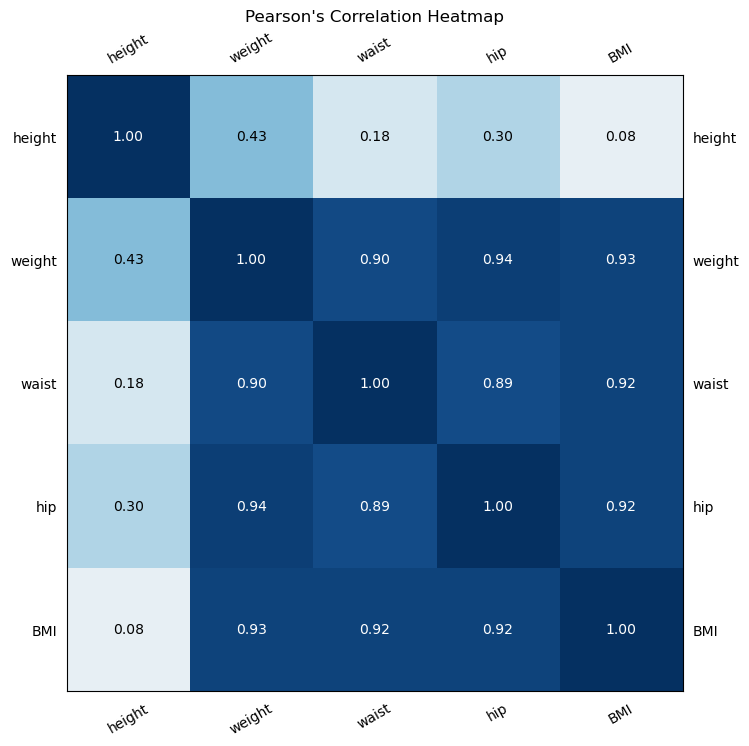

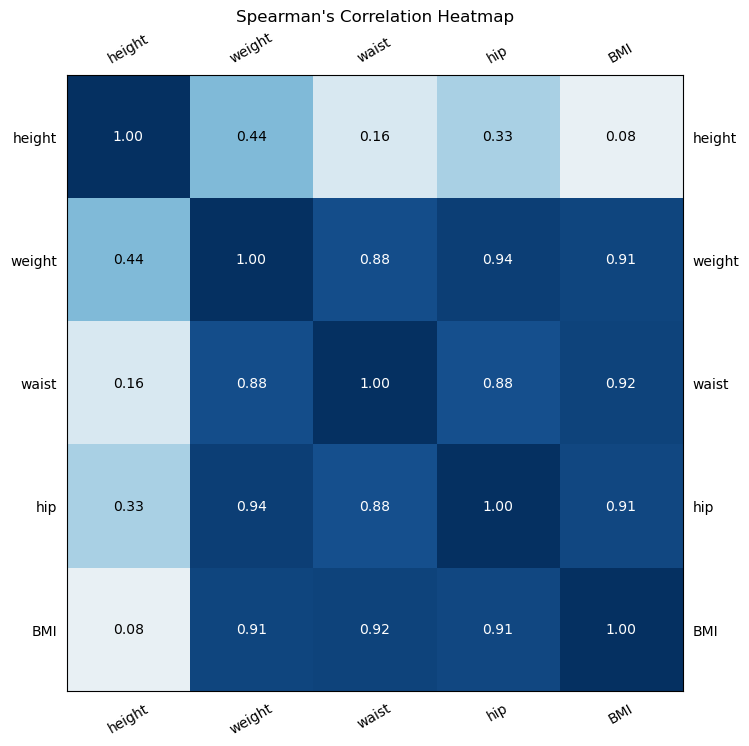

In [21]:
# Plot Pearson's correlation heatmap

plt.figure(figsize=(10, 8))  # width=height
plt.title("Pearson's Correlation Heatmap")
corrheatmap(pearson_corr_zmale, labels)
plt.show()

# Plot Spearman's correlation heatmap
plt.figure(figsize=(10, 8))  # width=height
plt.title("Spearman's Correlation Heatmap")
corrheatmap(spearman_corr_zmale, labels)
plt.show()

#### **Conclusion:**

1. **Gender Differences in BMI:**
   - Females have a higher average BMI (30.10) compared to males (29.14).
   - The BMI distribution for females shows greater variability (std: 7.76) compared to males (std: 6.31).

2. **Skewness and Outliers:**
   - Both BMI distributions are right-skewed.
   - Several outliers are observed for both genders, with BMI values exceeding 40 and up to around 65.

3. **Central Tendency and Variability:**
   - Mean BMI: Females (30) are slightly higher than males (29).
   - IQR for females is wider (25 to 35) than for males (26 to 32), indicating greater spread.

4. **Correlations:**
   - Strongest correlation: Weight and hip circumference (0.94).
   - Other strong correlations include weight and BMI (0.93) and waist and BMI (0.92).
   - Height shows weak correlations with other variables, indicating independence.

5. **Insights from Pairplot:**
   - Strong positive trends among weight, waist, hip, and BMI.
   - Outliers and skewness in distributions are visually evident.
   - Height is symmetrically distributed and less interrelated with other metrics.

6. **Practical Implications:**
   - Interdependence among weight, waist, hip, and BMI underscores their importance in body composition analysis.
   - Handling outliers and skewed data is essential for accurate health assessments.

7. **Summary:**
   - The analysis highlights gender differences, strong variable interrelations, and critical body composition trends, providing actionable insights for health evaluation and strategy development.